In [16]:
import pandas as pd

df = pd.read_csv("survey_results_public.csv", low_memory=False)
schema = pd.read_csv("survey_results_schema.csv")

print("df shape:", df.shape)
print("schema shape:", schema.shape)
display(schema.head())

df shape: (49191, 172)
schema shape: (139, 6)


,qid,qname,question,type,sub,sq_id
0,QID18,TechEndorse_1,What attracts you to a technology or causes yo...,RO,AI integration or AI Agent capabilities,1.0
1,QID18,TechEndorse_2,What attracts you to a technology or causes yo...,RO,Easy-to-use API,2.0
2,QID18,TechEndorse_3,What attracts you to a technology or causes yo...,RO,Robust and complete API,3.0
3,QID18,TechEndorse_4,What attracts you to a technology or causes yo...,RO,Customizable and manageable codebase,4.0
4,QID18,TechEndorse_5,What attracts you to a technology or causes yo...,RO,Reputation for quality,5.0


In [37]:
print("First 20 columns of the dataset:")
print(df.columns[:20])

print("\nSchema columns:")
print(schema.columns)

# common attempt: schema usually has a column with the variable name, like 'column' or 'qname'
possible_key_cols = [c for c in schema.columns if c.lower() in ["column", "qname", "columnname", "name"]]
print("\nPossible key columns in schema:", possible_key_cols)

First 20 columns of the dataset:
Index(['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment',
       'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode',
       'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize',
       'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro',
       'TechEndorse_1', 'TechEndorse_2'],
      dtype='object')

Schema columns:
Index(['qid', 'qname', 'question', 'type', 'sub', 'sq_id'], dtype='object')

Possible key columns in schema: ['qname']


In [38]:
# Create dictionary: qname -> question (full question text)
schema_dict = dict(zip(schema["qname"], schema["question"]))

# Examples (choose some columns you have)
for col in ["YearsCodePro", "RemoteWork", "EdLevel", "CompTotal", "DevType"]:
    if col in schema_dict:
        print(f"\n{col} -> {schema_dict[col]}")
    else:
        print(f"\n{col} -> (not in schema, could be technical or from another section)")


YearsCodePro -> (not in schema, could be technical or from another section)

RemoteWork -> Which best describes your current work situation?

EdLevel -> Which of the following best describes the highest level of formal education that you’ve completed? 

CompTotal -> What is your current total <b>annual</b> compensation (salary, bonuses, and perks, before taxes and deductions) in terms of your day-to-day currency?  Please enter a whole number in the box below, without any punctuation.  If you are paid hourly, please estimate an equivalent yearly salary. If you prefer not to answer, please leave the box empty. 

DevType -> Which of the following describes your current job or the job you had for the most time in the past year?


In [39]:
# 1) See compensation-related columns
comp_cols = [c for c in df.columns if "Comp" in c or "Salary" in c or "Currency" in c]
comp_cols

['Currency', 'CompTotal', 'AIComplex', 'ConvertedCompYearly']

In [40]:
# 2) See what values are in Currency and if CompFreq exists
if "Currency" in df.columns:
    print("Top currencies:\n", df["Currency"].value_counts().head(10), "\n")

if "CompFreq" in df.columns:
    print("CompFreq values:\n", df["CompFreq"].value_counts(dropna=False), "\n")

# 3) See CompTotal (cleaned)
if "CompTotal" in df.columns:
    print(df["CompTotal"].describe())

Top currencies:
 Currency
EUR European Euro           9618
USD United States dollar    8780
INR Indian rupee            2484
GBP Pound sterling          2047
CAD Canadian dollar         1283
PLN Polish zloty             826
AUD\tAustralian dollar       800
BRL Brazilian real           775
UAH Ukrainian hryvnia        622
SEK\tSwedish krona           601
Name: count, dtype: int64 

count    2.486600e+04
mean     2.234198e+70
std      3.523096e+72
min      0.000000e+00
25%      5.500000e+04
50%      1.050000e+05
75%      2.400000e+05
max      5.555556e+74
Name: CompTotal, dtype: float64


In [41]:
# Base dataset: we keep simple columns to start
base_features = ["YearsCodePro", "EdLevel", "RemoteWork", "OrgSize", "Employment", "DevType"]
base_features = [c for c in base_features if c in df.columns]

target_col = "CompTotal"  # for now
keep_cols = base_features + ["Currency", target_col]
keep_cols = [c for c in keep_cols if c in df.columns]

data = df[keep_cols].copy()

# Convert CompTotal to numeric
data[target_col] = pd.to_numeric(data[target_col], errors="coerce")

# Filter: CompTotal and Currency must exist
data = data.dropna(subset=[target_col, "Currency"])

# Example: keep only USD (you can change it later)
data_usd = data[data["Currency"] == "USD"].copy()

print("Rows total:", data.shape[0])
print("Rows USD:", data_usd.shape[0])
data_usd.head()

Rows total: 24866
Rows USD: 0


,EdLevel,RemoteWork,OrgSize,Employment,DevType,Currency,CompTotal


In [42]:
# Create a column with the clean currency code (only "USD", "EUR", etc.)
data["CurrencyCode"] = data["Currency"].astype(str).str.split().str[0]

# Check that they now appear
print(data["CurrencyCode"].value_counts().head(10))

# Filter USD correctly
data_usd = data[data["CurrencyCode"] == "USD"].copy()

print("Rows total:", data.shape[0])
print("Rows USD:", data_usd.shape[0])
data_usd.head()

CurrencyCode
EUR    7054
USD    6564
GBP    1551
INR    1237
CAD     942
BRL     606
AUD     577
PLN     553
SEK     467
UAH     431
Name: count, dtype: int64
Rows total: 24866
Rows USD: 6564


,EdLevel,RemoteWork,OrgSize,Employment,DevType,Currency,CompTotal,CurrencyCode
4,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",NaN,NaN,"Independent contractor, freelancer, or self-em...",Engineering manager,USD United States dollar,60000.0,USD
5,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",NaN,NaN,"Independent contractor, freelancer, or self-em...","Developer, back-end",USD United States dollar,120000.0,USD
6,Some college/university study without earning ...,NaN,NaN,"Independent contractor, freelancer, or self-em...","Developer, full-stack",USD United States dollar,6240.0,USD
7,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Remote,Less than 20 employees,Employed,"Architect, software or solutions",USD United States dollar,72000.0,USD
8,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Remote,"5,000 to 9,999 employees",Employed,Data engineer,USD United States dollar,70000.0,USD


In [43]:
import numpy as np
import pandas as pd

salary_col = "ConvertedCompYearly"

# Selection of simple features (the ones you are already using)
base_features = ["YearsCodePro", "EdLevel", "RemoteWork", "OrgSize", "Employment", "DevType"]
base_features = [c for c in base_features if c in df.columns]

data2 = df[base_features + [salary_col]].copy()

# Convert to numeric
data2[salary_col] = pd.to_numeric(data2[salary_col], errors="coerce")

# Remove nulls and invalid salaries
data2 = data2.dropna(subset=[salary_col])
data2 = data2[data2[salary_col] > 0].copy()

print("Rows with ConvertedCompYearly valid:", data2.shape[0])
data2.head()

Rows with ConvertedCompYearly valid: 23947


,EdLevel,RemoteWork,OrgSize,Employment,DevType,ConvertedCompYearly
0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,20 to 99 employees,Employed,"Developer, mobile",61256.0
1,"Associate degree (A.A., A.S., etc.)","Hybrid (some in-person, leans heavy to flexibi...",500 to 999 employees,Employed,"Developer, back-end",104413.0
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,NaN,"Independent contractor, freelancer, or self-em...","Developer, front-end",53061.0
3,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Remote,"10,000 or more employees",Employed,"Developer, back-end",36197.0
4,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",NaN,NaN,"Independent contractor, freelancer, or self-em...",Engineering manager,60000.0


In [44]:
# Remove extreme outliers (e.g., clip at 99th percentile)
p99 = data2[salary_col].quantile(0.99)
data2 = data2[data2[salary_col] <= p99].copy()

print("Rows after removing p99 outliers:", data2.shape[0])
print("p99:", p99)

Rows after removing p99 outliers: 23708
p99: 440856.0


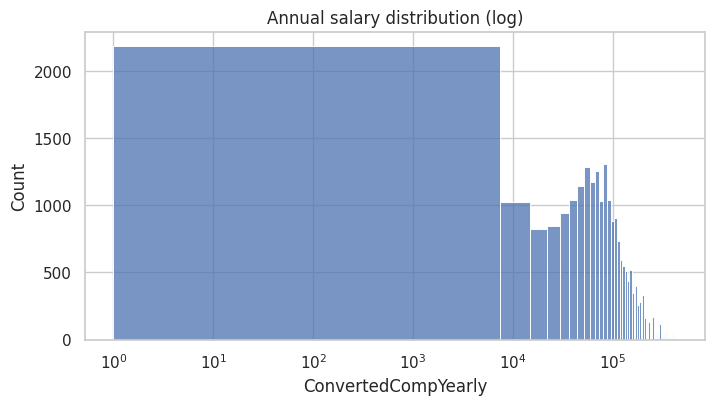

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(8,4))
sns.histplot(data2[salary_col], bins=60)
plt.xscale("log")
plt.title("Annual salary distribution (log)")
plt.show()

In [45]:
salary_col = "ConvertedCompYearly"

# Percentiles to see extremes (1%, 50%, 99%)
data2[salary_col].quantile([0.01, 0.5, 0.99])
data2[salary_col].describe()

,ConvertedCompYearly
count,23708.000000
mean,87329.771259
std,69468.600289
min,1.000000
25%,37410.500000
50%,74878.000000
75%,120000.000000
max,440856.000000


In [46]:
p01 = data2[salary_col].quantile(0.01)
p99 = data2[salary_col].quantile(0.99)

data3 = data2[(data2[salary_col] >= p01) & (data2[salary_col] <= p99)].copy()

print("Rows before:", data2.shape[0])
print("Rows after (p01-p99):", data3.shape[0])
print("p01:", p01, "| p99:", p99)

Rows before: 23708
Rows after (p01-p99): 23246
p01: 65.0 | p99: 330000.0


In [53]:
median_salary = data3[salary_col].median()
data3["high_salary"] = (data3[salary_col] > median_salary).astype(int)

print("Median:", median_salary)
print(data3["high_salary"].value_counts(normalize=True))

Median: 74878.0
high_salary
0    0.501118
1    0.498882
Name: proportion, dtype: float64


In [29]:
from sklearn.model_selection import train_test_split

features = ["YearsCodePro", "EdLevel", "RemoteWork", "OrgSize", "Employment", "DevType"]
features = [c for c in features if c in data3.columns]

X = data3[features]
y = data3["high_salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((18596, 5), (4650, 5))

In [52]:
features = [c for c in features if c in data3.columns]
print("Used features :", features)
print("Number of features:", len(features))

Used features : ['EdLevel', 'RemoteWork', 'OrgSize', 'Employment', 'DevType']
Number of features: 5


In [47]:
import numpy as np
import pandas as pd

def clean_years_code_pro(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s.lower().startswith("less than"):
        return 0.5
    if s.lower().startswith("more than"):
        return 51.0
    try:
        return float(s)
    except:
        return np.nan

# apply if exists in features
if "YearsCodePro" in X_train.columns:
    X_train = X_train.copy()
    X_test = X_test.copy()
    X_train["YearsCodePro"] = X_train["YearsCodePro"].apply(clean_years_code_pro)
    X_test["YearsCodePro"] = X_test["YearsCodePro"].apply(clean_years_code_pro)

X_train.head()

,EdLevel,RemoteWork,OrgSize,Employment,DevType
4981,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",In-person,100 to 499 employees,Employed,System administrator
17876,"Associate degree (A.A., A.S., etc.)",Remote,"1,000 to 4,999 employees",Employed,"Developer, full-stack"
3956,"Secondary school (e.g. American high school, G...",In-person,20 to 99 employees,Employed,"Developer, embedded applications or devices"
4625,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Remote,20 to 99 employees,Employed,"Developer, full-stack"
32275,Some college/university study without earning ...,Remote,100 to 499 employees,Employed,"Developer, desktop or enterprise applications"


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression

# separate numerical/categorical
numeric_features = []
categorical_features = []

for c in X_train.columns:
    if c == "YearsCodePro":
        numeric_features.append(c)     # we have already cleaned it to numeric
    else:
        categorical_features.append(c) # the rest are treated as categorical for simplicity

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

model_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

model_lr.fit(X_train, y_train)

pred = model_lr.predict(X_test)
proba = model_lr.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, proba))
print("\nClassification report:\n", classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
print("\nConfusion matrix:\n", cm)

AUC: 0.6891105520201273

Classification report:
               precision    recall  f1-score   support

           0       0.65      0.57      0.61      2330
           1       0.62      0.69      0.65      2320

    accuracy                           0.63      4650
   macro avg       0.63      0.63      0.63      4650
weighted avg       0.63      0.63      0.63      4650


Confusion matrix:
 [[1336  994]
 [ 714 1606]]


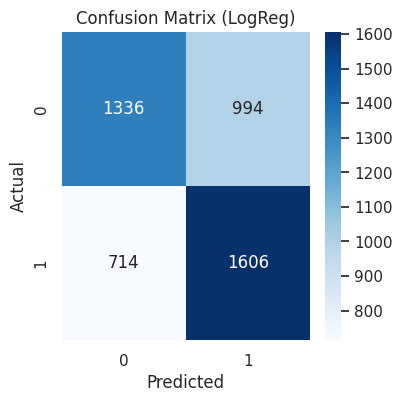

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (LogReg)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
# Get column names after one-hot encoding
ohe = model_lr.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)

all_names = np.concatenate([np.array(numeric_features), cat_names])

coefs = model_lr.named_steps["model"].coef_[0]
coef_series = pd.Series(coefs, index=all_names).sort_values()

print("TOP factors that REDUCE high_salary probability:")
display(coef_series.head(10))

print("\nTOP factors that INCREASE high_salary probability:")
display(coef_series.tail(10))

TOP factors that REDUCE high_salary probability:


,0
Employment_Student,-1.823265
DevType_Student,-1.428648
DevType_Academic researcher,-1.152180
"OrgSize_Just me - I am a freelancer, sole proprietor, etc.",-0.908289
"DevType_Developer, QA or test",-0.732813
RemoteWork_In-person,-0.716166
EdLevel_Other (please specify):,-0.617543
OrgSize_Less than 20 employees,-0.600225
DevType_Data or business analyst,-0.582423
"DevType_Developer, front-end",-0.539183



TOP factors that INCREASE high_salary probability:


,0
"DevType_Founder, technology or otherwise",0.496329
DevType_Applied scientist,0.509698
"OrgSize_10,000 or more employees",0.521077
DevType_Cybersecurity or InfoSec professional,0.564424
"DevType_Architect, software or solutions",0.614015
Employment_Employed,0.624154
"EdLevel_Professional degree (JD, MD, Ph.D, Ed.D, etc.)",0.643314
DevType_Product manager,0.739759
"DevType_Senior executive (C-suite, VP, etc.)",1.117737
DevType_Engineering manager,1.276290


In [50]:
import pandas as pd

# NOTE: use exactly the columns you used in X_train (your 5 features)
used_features = ['EdLevel', 'RemoteWork', 'OrgSize', 'Employment', 'DevType']

# Profile A: junior/less favored profile according to coefficients (example)
perfil_A = {
    "EdLevel": "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",
    "RemoteWork": "In-person",
    "OrgSize": "Less than 20 employees",
    "Employment": "Student",
    "DevType": "Student"
}

# Profile B: "high" profile according to coefficients (example)
perfil_B = {
    "EdLevel": "Professional degree (JD, MD, Ph.D, Ed.D, etc.)",
    "RemoteWork": "Remote",
    "OrgSize": "10,000 or more employees",
    "Employment": "Employed",
    "DevType": "Engineering manager"
}

X_scenarios = pd.DataFrame([perfil_A, perfil_B])[used_features]

# Probabilities
probas = model_lr.predict_proba(X_scenarios)[:, 1]
resultados = pd.DataFrame({
    "Perfil": ["A (base profile)", "B (high profile)"],
    "Prob(high_salary)": probas
})

resultados

,Perfil,Prob(high_salary)
0,A (base profile),0.003798
1,B (high profile),0.944422


In [51]:
salary_col = "ConvertedCompYearly"

base_features2 = ["YearsCodePro", "EdLevel", "RemoteWork", "OrgSize", "Employment", "DevType"]
base_features2 = [c for c in base_features2 if c in df.columns]

data_exp = df[base_features2 + [salary_col]].copy()
data_exp[salary_col] = pd.to_numeric(data_exp[salary_col], errors="coerce")
data_exp = data_exp.dropna(subset=[salary_col])
data_exp = data_exp[data_exp[salary_col] > 0].copy()

# p01-p99 clipping
p01 = data_exp[salary_col].quantile(0.01)
p99 = data_exp[salary_col].quantile(0.99)
data_exp = data_exp[(data_exp[salary_col] >= p01) & (data_exp[salary_col] <= p99)].copy()

# binary target
median_salary = data_exp[salary_col].median()
data_exp["high_salary"] = (data_exp[salary_col] > median_salary).astype(int)

data_exp.columns

Index(['EdLevel', 'RemoteWork', 'OrgSize', 'Employment', 'DevType',
       'ConvertedCompYearly', 'high_salary'],
      dtype='object')